# ⚽ CDAF: Exploratory Data Analysis (EDA)
**Dataset:** Bundesliga 24/25 - CazéTV Live Chat

Este notebook realiza uma análise estatística e visual completa de todo o corpus de mensagens coletadas, seguindo as melhores práticas de Data Science.

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import glob
import numpy as np

# Configuração Global
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

def t2s(t): 
    if not t: return 0
    parts = list(map(int, t.split(':')))
    return parts[0]*3600 + parts[1]*60 + parts[2] if len(parts)==3 else parts[0]*60 + parts[1]

## 1. Data Ingestion & Consolidation
Carregamos todos os 66 arquivos CSV processados em um único DataFrame mestre.

In [40]:
processed_files = glob.glob('data/processed/chat_*_processed.csv')
dfs = []

for f in processed_files:
    video_id = os.path.basename(f).split('_')[1]
    temp_df = pd.read_csv(f)
    temp_df['video_id'] = video_id
    dfs.append(temp_df)

master_df = pd.concat(dfs, ignore_index=True)

# Conversão de tipos para eficiência
master_df['periodo'] = master_df['periodo'].astype('category')
master_df['minuto_arredondado'] = master_df['timestamp_jogo_segundos'] // 60

print(f"Dataset consolidado com sucesso!")
print(f"Total de mensagens: {len(master_df):,}")
print(f"Total de partidas (arquivos): {len(processed_files)}")
master_df.head()

Dataset consolidado com sucesso!
Total de mensagens: 246,918
Total de partidas (arquivos): 65


,timestamp_video_segundos,timestamp_jogo_segundos,label_partida,periodo,autor,mensagem,video_id,minuto_arredondado
0,0.000,-2953.000,-49',Pré-jogo,@muriloconstante5027,vamo bayerrrr,QNZwsNZQeHI,-50.0
1,0.000,-2953.000,-49',Pré-jogo,@Lhzin_2011,bayernnnnn,QNZwsNZQeHI,-50.0
2,0.000,-2953.000,-49',Pré-jogo,@reinaldobenedete353,Vai Brasil,QNZwsNZQeHI,-50.0
3,0.000,-2953.000,-49',Pré-jogo,@claudiodaconceicaoazeredo4151,Bom dia,QNZwsNZQeHI,-50.0
4,87.759,-2865.241,-47',Pré-jogo,@viniciusgamer1991,Bayer 5a0hoje,QNZwsNZQeHI,-48.0


## 2. Estatísticas de Alto Nível
Entendendo o volume e a abrangência dos dados.

In [41]:
summary = {
    "Total Mensagens": len(master_df),
    "Autores Únicos": master_df['autor'].nunique(),
    "Média Mensagens por Jogo": len(master_df) / len(processed_files),
    "Mensagem mais comum": str(master_df['mensagem'].mode()[0]),
    "Frequência do Top 1": master_df['mensagem'].value_counts().iloc[0]
}

pd.Series(summary).to_frame(name="Valor")

,Valor
Total Mensagens,246918
Autores Únicos,71262
Média Mensagens por Jogo,3798.738462
Mensagem mais comum,gol
Frequência do Top 1,1078


## 3. Análise Temporal (Engajamento na Temporada)
Volume médio de mensagens por minuto em todas as partidas.

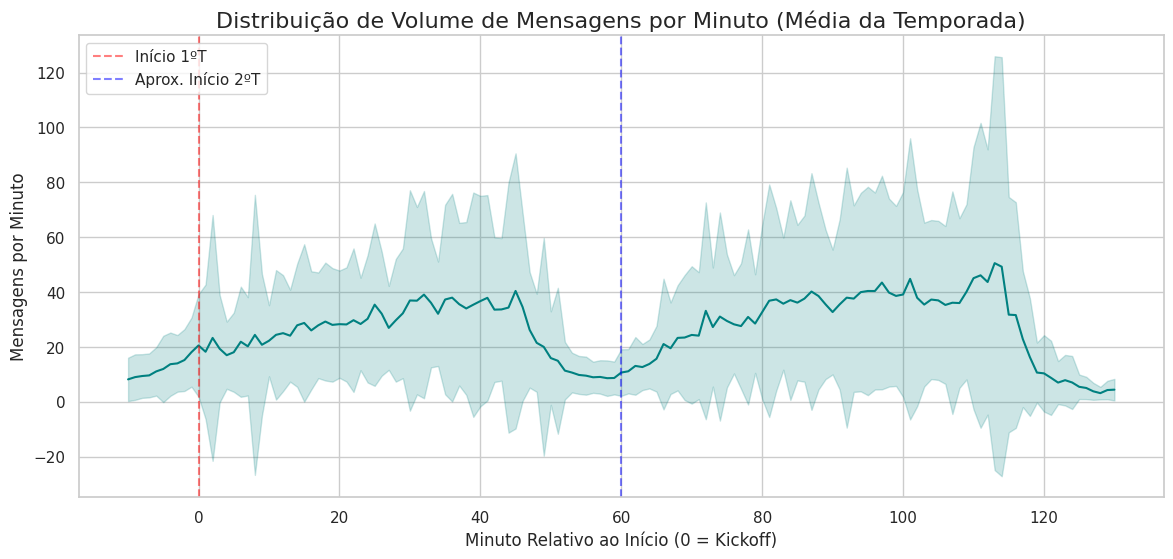

In [42]:
# Agrupar por Video e Minuto para calcular a média da temporada
min_counts = master_df.groupby(['video_id', 'minuto_arredondado']).size().reset_index(name='count')

# Filtrar range relevante
min_counts = min_counts[(min_counts['minuto_arredondado'] >= -10) & (min_counts['minuto_arredondado'] <= 130)]

plt.figure(figsize=(14, 6))
sns.lineplot(data=min_counts, x='minuto_arredondado', y='count', color='teal', errorbar='sd')
plt.title('Distribuição de Volume de Mensagens por Minuto (Média da Temporada)', fontsize=16)
plt.xlabel('Minuto Relativo ao Início (0 = Kickoff)')
plt.ylabel('Mensagens por Minuto')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Início 1ºT')
plt.axvline(x=60, color='blue', linestyle='--', alpha=0.5, label='Aprox. Início 2ºT')
plt.legend()
plt.show()

## 4. Análise por Período
Onde está o maior engajamento?

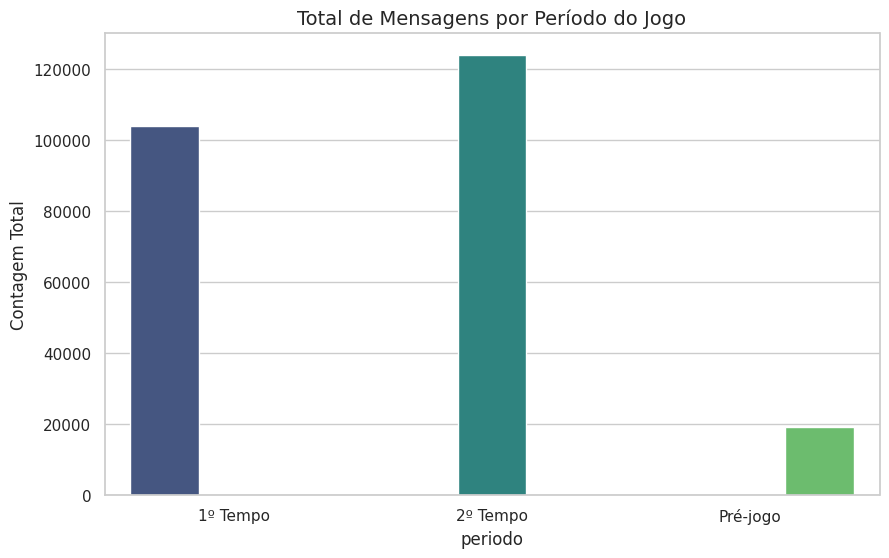

In [43]:
plt.figure(figsize=(10, 6))
periodo_counts = master_df['periodo'].value_counts().sort_values(ascending=False)
sns.barplot(x=periodo_counts.index, y=periodo_counts.values, hue=periodo_counts.index, palette='viridis', legend=False)
plt.title('Total de Mensagens por Período do Jogo', fontsize=14)
plt.ylabel('Contagem Total')
plt.show()

## 5. Distribuição de Autores
Identificando o comportamento dos usuários.

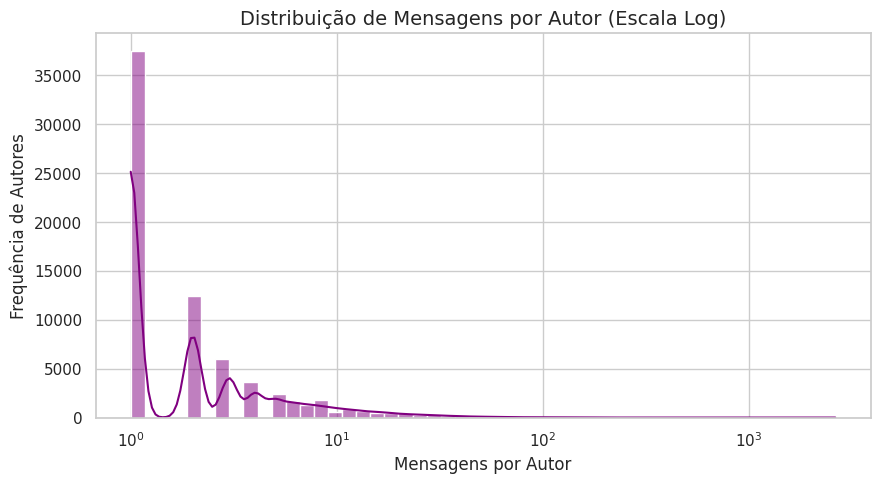

Top 10 Autores mais ativos (Super-fans):
autor
@StreamElements                  2617
@oliveirasilva1224                378
@CazeTV                           317
@TarcisiodeOliveiraCavalcante     315
@Gokhan1984-d9q                   311
@Gustavobarbosaoriginsl           224
@PedroFreire11                    205
@MrGugas2                         203
@filipes.7317                     194
@carlloscesar2129                 184
Name: count, dtype: int64


In [44]:
user_counts = master_df['autor'].value_counts()

plt.figure(figsize=(10, 5))
sns.histplot(user_counts, bins=50, kde=True, color='purple', log_scale=True)
plt.title('Distribuição de Mensagens por Autor (Escala Log)', fontsize=14)
plt.xlabel('Mensagens por Autor')
plt.ylabel('Frequência de Autores')
plt.show()

print("Top 10 Autores mais ativos (Super-fans):")
print(user_counts.head(10))

## 6. Heatmap de Atividade Sazonal
Cada linha representa um jogo diferente ao longo da temporada.

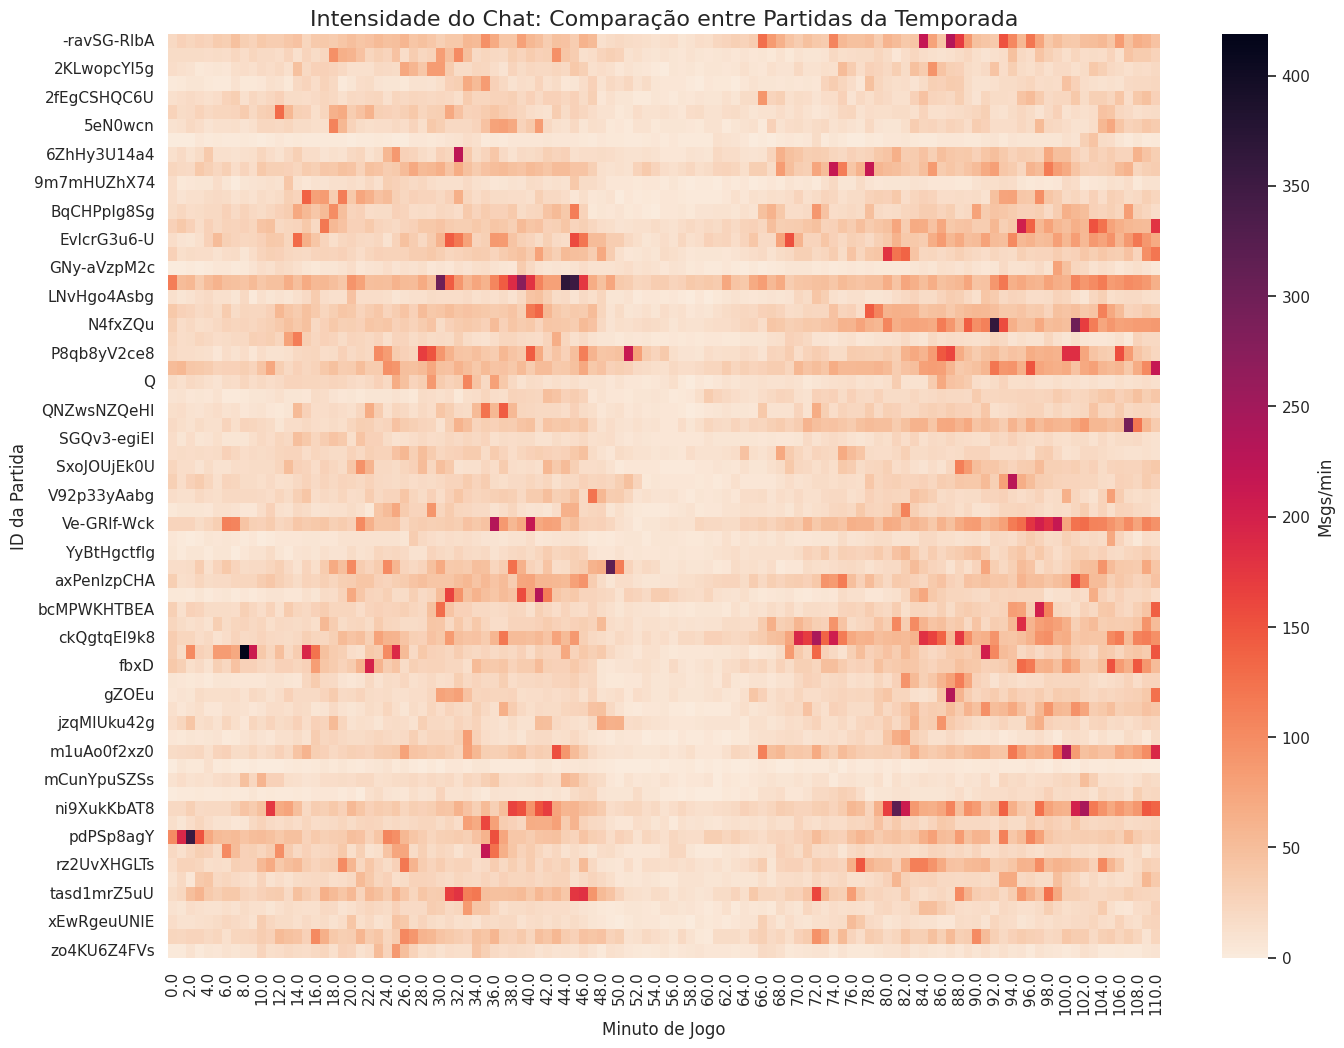

In [45]:
pivot_table = master_df.pivot_table(index='video_id', columns='minuto_arredondado', values='mensagem', aggfunc='count').fillna(0)
pivot_table = pivot_table.loc[:, 0:110]

plt.figure(figsize=(16, 12))
sns.heatmap(pivot_table, cmap='rocket_r', cbar_kws={'label': 'Msgs/min'})
plt.title('Intensidade do Chat: Comparação entre Partidas da Temporada', fontsize=16)
plt.xlabel('Minuto de Jogo')
plt.ylabel('ID da Partida')
plt.show()

## 7. Tamanho das Mensagens
Distribuição do comprimento do texto.

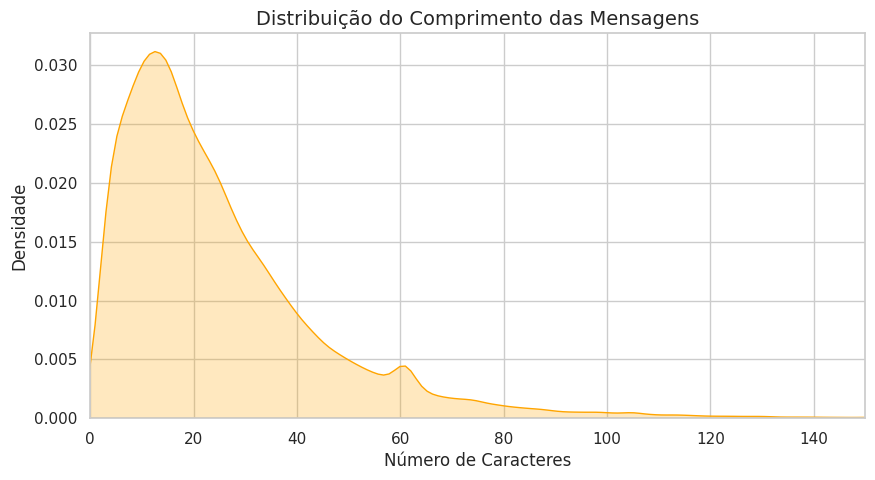

In [46]:
master_df['msg_len'] = master_df['mensagem'].astype(str).str.len()

plt.figure(figsize=(10, 5))
sns.kdeplot(data=master_df, x='msg_len', fill=True, color='orange')
plt.title('Distribuição do Comprimento das Mensagens', fontsize=14)
plt.xlabel('Número de Caracteres')
plt.ylabel('Densidade')
plt.xlim(0, 150)
plt.show()

## 8. Engajamento por Time
Qual é a média de comentários por jogo para cada equipe da Bundesliga?

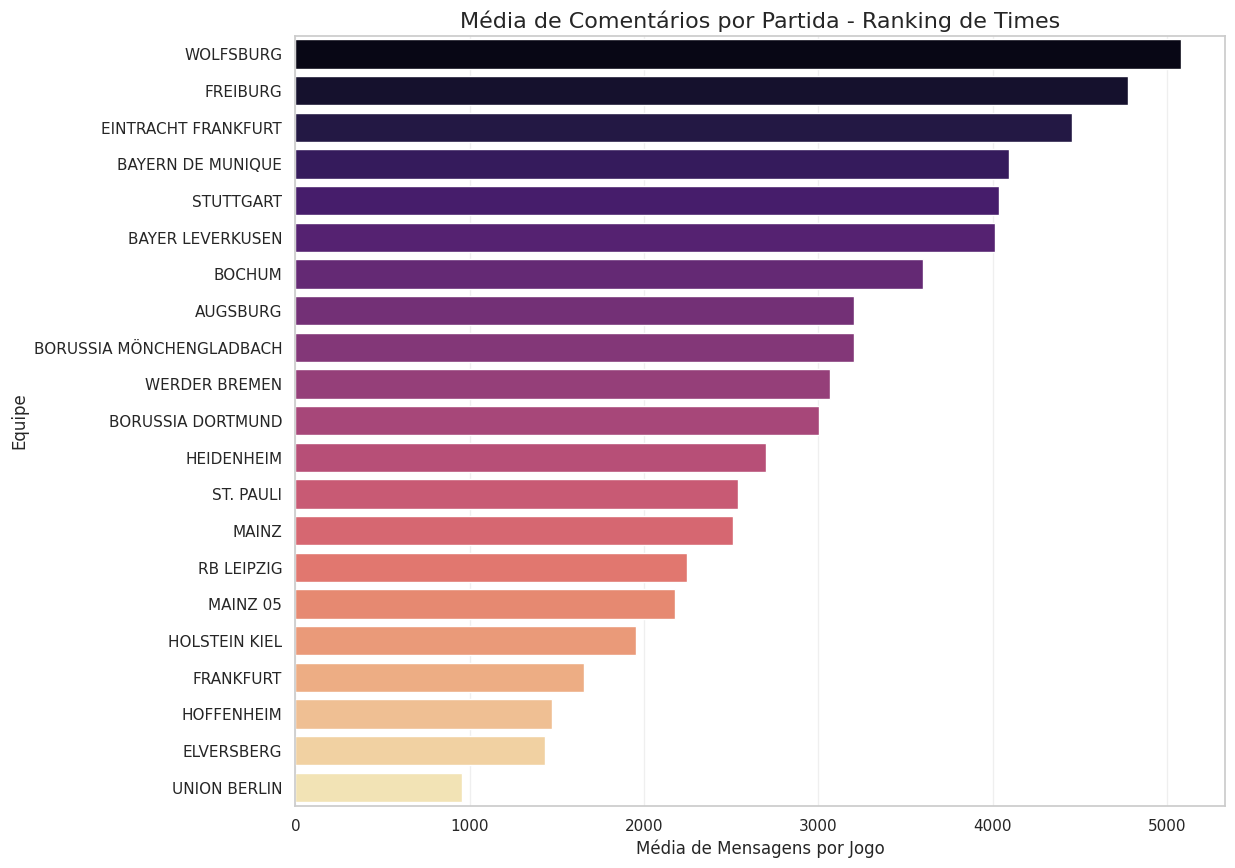

Top 5 Times com maior engajamento médio:
time
WOLFSBURG              5080.500000
FREIBURG               4773.666667
EINTRACHT FRANKFURT    4453.750000
BAYERN DE MUNIQUE      4091.590909
STUTTGART              4035.000000
Name: mensagens, dtype: float64


In [47]:
import re

with open('config/video_info.json', 'r') as f:
    videos_info_raw = json.load(f)
    v_info_dict = {v['video_id']: v['title'] for v in videos_info_raw}

def extract_teams(title):
    # Padrão: "JOGO COMPLETO: TIME A X TEAM B | ..."
    match = re.search(r'JOGO COMPLETO: (.*?) \|', title)
    if match:
        teams_part = match.group(1)
        teams = re.split(r' [xX] ', teams_part)
        return [t.strip() for t in teams]
    return []

# 1. Mapear jogos para times e contar mensagens por jogo
match_counts = master_df['video_id'].value_counts().to_dict()
team_data = []

for v_id, title in v_info_dict.items():
    teams = extract_teams(title)
    msg_count = match_counts.get(v_id, 0)
    for team in teams:
        team_data.append({'time': team, 'mensagens': msg_count})

team_df = pd.DataFrame(team_data)

# 2. Calcular a média por time
team_avg = team_df.groupby('time')['mensagens'].mean().sort_values(ascending=False)

# 3. Plotar
plt.figure(figsize=(12, 10))
sns.barplot(x=team_avg.values, y=team_avg.index, hue=team_avg.index, palette='magma', legend=False)
plt.title('Média de Comentários por Partida - Ranking de Times', fontsize=16)
plt.xlabel('Média de Mensagens por Jogo')
plt.ylabel('Equipe')
plt.grid(True, axis='x', alpha=0.3)
plt.show()

print("Top 5 Times com maior engajamento médio:")
print(team_avg.head(5))

## 9. Exportação Final
Consolidamos todos os comentários com títulos dos vídeos e exportamos para um arquivo Parquet.

In [48]:
# Mapear títulos para o dataframe mestre
master_df['video_title'] = master_df['video_id'].map(v_info_dict)

# Selecionar e organizar colunas para exportação
export_df = master_df[[
    'video_id', 
    'video_title', 
    'periodo', 
    'label_partida', 
    'timestamp_video_segundos', 
    'timestamp_jogo_segundos', 
    'autor', 
    'mensagem'
]]

output_parquet = 'bundesliga_2425_cazetv_chat.parquet'
export_df = export_df.copy()
for col in export_df.columns:
    export_df[col] = export_df[col].astype(object)
export_df.to_parquet(output_parquet, index=False, engine='fastparquet')

print(f"Exportação concluída com sucesso!")
print(f"Arquivo gerado: {output_parquet}")
print(f"Tamanho final: {len(export_df):,} linhas.")

ArrowKeyError: A type extension with name pandas.period already defined